In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [32]:
# ================================
# Loading and Explore the Dataset
# ================================
df = pd.read_csv('car data.csv')  # Make sure the file is in your working directory

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (301, 9)

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Sellin

In [33]:
# ================================
# 2. DROPPING UNNECESSARY COLUMNS 
# ================================
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)
    print("\n Dropped 'Car_Name' column")


 Dropped 'Car_Name' column



Unique values in categorical columns:
Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Selling_type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']


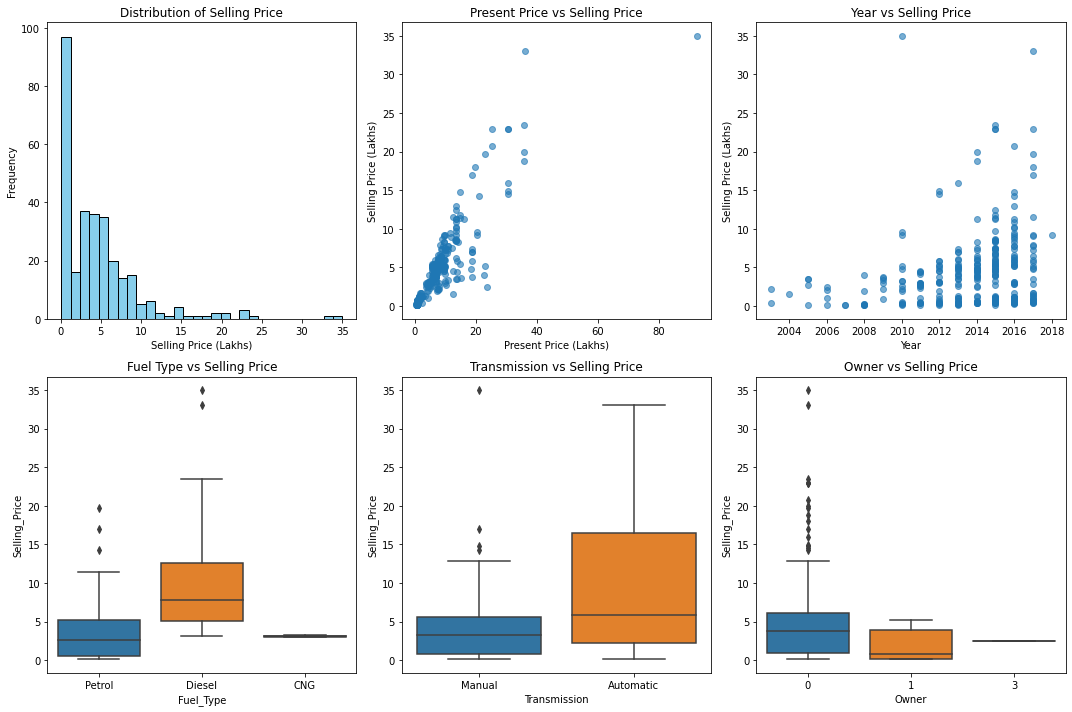

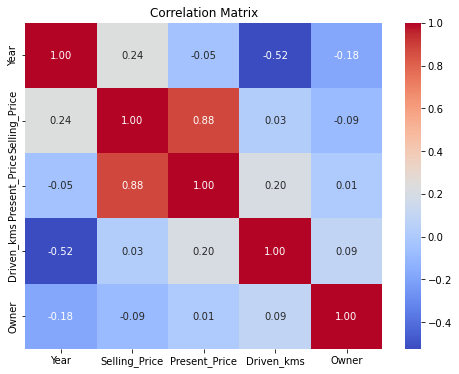

In [34]:
# ================================
# Exploratory Data Analysis (EDA)
# ================================
# Checking unique values in categorical columns

print("\nUnique values in categorical columns:")
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# Distribution of Selling Price
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.hist(df['Selling_Price'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
plt.scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6)
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(2, 3, 3)
plt.scatter(df['Year'], df['Selling_Price'], alpha=0.6)
plt.title('Year vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price (Lakhs)')

plt.subplot(2, 3, 4)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Fuel Type vs Selling Price')

plt.subplot(2, 3, 5)
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title('Transmission vs Selling Price')

plt.subplot(2, 3, 6)
sns.boxplot(x='Owner', y='Selling_Price', data=df)
plt.title('Owner vs Selling Price')

plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features
numerical_cols = ['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [35]:
# ================================
# Feature Engineering
# ================================


# Calculate car age
df['Car_Age'] = 2024 - df['Year']  # Current year 2024

# Dropping original Year column
df.drop('Year', axis=1, inplace=True)

print("\nFeatures after engineering:")
print(df.columns.tolist())



Features after engineering:
['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [36]:
label_encoders = {}
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']

print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} Encoding:")
    for class_name, encoded_value in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {class_name} -> {encoded_value}")


ENCODING CATEGORICAL VARIABLES

Fuel_Type Encoding:
  CNG -> 0
  Diesel -> 1
  Petrol -> 2

Selling_type Encoding:
  Dealer -> 0
  Individual -> 1

Transmission Encoding:
  Automatic -> 0
  Manual -> 1


In [37]:
# ================================
# Separate Features and Target
# ================================
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print("\nFeatures:", X.columns.tolist())
print("Target: Selling_Price")



Features: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
Target: Selling_Price


In [38]:
# ================================
# Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")



Training set size: 240 samples
Test set size: 61 samples


In [39]:
# ================================
# Feature Scaling (for Linear Regression)
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [40]:
# ================================
#  Model Training & Evaluation
# ================================
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    if name == 'Linear Regression':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    }
    
    print(f"\n{'='*40}")
    print(f"{name} Results:")
    print(f"{'='*40}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Cross-validation R² (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



Linear Regression Results:
MAE: 1.2219
MSE: 3.5316
RMSE: 1.8792
R² Score: 0.8467
Cross-validation R² (mean): 0.8440 (+/- 0.0388)

Decision Tree Results:
MAE: 0.8484
MSE: 2.0600
RMSE: 1.4353
R² Score: 0.9106
Cross-validation R² (mean): 0.8696 (+/- 0.1078)

Random Forest Results:
MAE: 0.6389
MSE: 0.9383
RMSE: 0.9686
R² Score: 0.9593
Cross-validation R² (mean): 0.8832 (+/- 0.0607)


In [ ]:
# ================================
# Hyperparameter Tuning for Random Forest
# ================================
print("\n" + "="*50)
print("Hyperparameter Tuning for Random Forest")
print("="*50)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
print(f"Test Set R² Score with tuned model: {r2_tuned:.4f}")



Hyperparameter Tuning for Random Forest
Fitting 5 folds for each of 108 candidates, totalling 540 fits


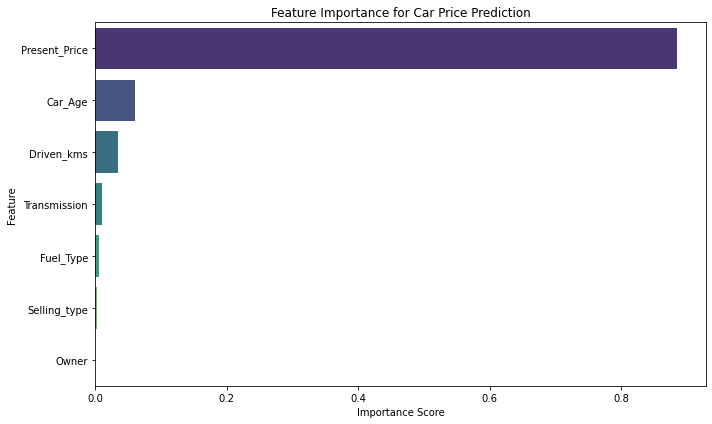


Feature Importance:
         Feature  Importance
0  Present_Price    0.884504
6        Car_Age    0.060462
1     Driven_kms    0.034973
4   Transmission    0.009999
2      Fuel_Type    0.006507
3   Selling_type    0.003489
5          Owner    0.000067


In [47]:
# ================================
# Feature Importance (Random Forest)
# ================================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance for Car Price Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)


In [51]:
# ================================
#  Making Predictions on New Data
# ================================
def predict_car_price(car_name, year, present_price, driven_kms, fuel_type, 
                      selling_type, transmission, owner):
    """
    Predict car selling price
    """
    car_age = 2024 - year
    
    # Encode categorical variables
    fuel_encoded = label_encoders['Fuel_Type'].transform([fuel_type])[0]
    selling_encoded = label_encoders['Selling_type'].transform([selling_type])[0]
    trans_encoded = label_encoders['Transmission'].transform([transmission])[0]
    
    # Creating feature array 
    features = np.array([[car_age, present_price, driven_kms, fuel_encoded, 
                          selling_encoded, trans_encoded, owner]])
    
    # Predicting
    predicted_price = best_rf.predict(features)[0]
    
    print(f"\n{'='*50}")
    print(f"Car: {car_name}")
    print(f"{'='*50}")
    print(f"Year: {year} (Age: {car_age} years)")
    print(f"Present Price: ₹{present_price} Lakhs")
    print(f"Kilometers Driven: {driven_kms} km")
    print(f"Fuel Type: {fuel_type}")
    print(f"Selling Type: {selling_type}")
    print(f"Transmission: {transmission}")
    print(f"Previous Owners: {owner}")
    print(f"\n Predicted Selling Price: ₹{predicted_price:.2f} Lakhs")
    
    return predicted_price

# Example prediction
example_price = predict_car_price(
    car_name="Honda City",
    year=2018,
    present_price=12.5,
    driven_kms=30000,
    fuel_type="Petrol",
    selling_type="Dealer",
    transmission="Manual",
    owner=0
)



Car: Honda City
Year: 2018 (Age: 6 years)
Present Price: ₹12.5 Lakhs
Kilometers Driven: 30000 km
Fuel Type: Petrol
Selling Type: Dealer
Transmission: Manual
Previous Owners: 0

 Predicted Selling Price: ₹5.45 Lakhs


In [52]:
# ================================
# Saving the Model 
# ================================
import joblib

# Save the best model and preprocessors
joblib.dump(best_rf, 'car_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("\n Model saved as 'car_price_model.pkl'")


 Model saved as 'car_price_model.pkl'


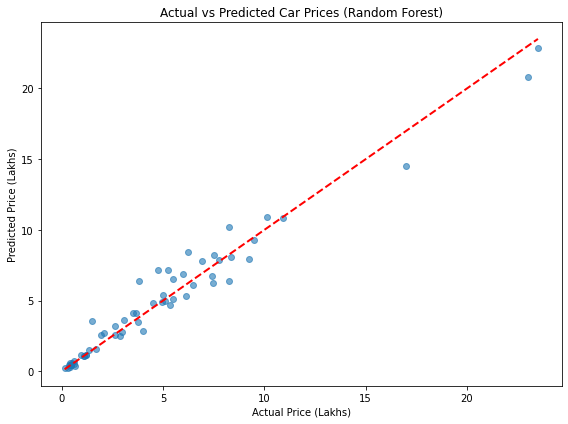

In [54]:
# ================================
# Visualizing Predictions vs Actual
# ================================
plt.figure(figsize=(8, 6))
y_pred_final = best_rf.predict(X_test)
plt.scatter(y_test, y_pred_final, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted Car Prices (Random Forest)')
plt.tight_layout()
plt.show()

In [55]:
# ================================
#  Displaying the Final Results Summary
# ================================
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Best Model: Random Forest with R² Score: {r2_tuned:.4f}")
print(f"Top 3 Important Features:")
for i in range(min(3, len(feature_importance))):
    print(f"  {i+1}. {feature_importance.iloc[i]['Feature']}: {feature_importance.iloc[i]['Importance']:.4f}")


FINAL RESULTS SUMMARY
Best Model: Random Forest with R² Score: 0.9593
Top 3 Important Features:
  1. Present_Price: 0.8845
  2. Car_Age: 0.0605
  3. Driven_kms: 0.0350
